# Zadaća

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — Kaggle  

### Zadatak:
1. **Pronađite vlastiti dataset** na [kaggle.com](https://kaggle.com) koji ima:
   - Numeričke feature-e (barem 3-4 kolone)
   - Klasifikacijski target (kategoričke labele)
   - Preporučeni tematski domen: sport, muzika, health, gaming, food — nešto što vas zanima!

2. **Istrenirajte MLP** (sklearn ili Keras — vaš izbor) i pokažite:
   - Preprocessing s `StandardScaler`
   - Barem 2 različite arhitekture (uporedite ih!)
   - F1 score i classification report za najbolji model
   - Kriva učenja (loss_curve_ ili Keras historija)

3. **Napišite komentar** (markdown ćelija na kraju): Šta ste primijetili? Je li veća mreža uvijek bolja? Koliko epoha je trebalo?

### Urađeni zadtak postavite na:
```
GitHub repo → 2026/Zadace/Vj8/<VasePrezimeIme>/vjezba_8_zadatak.ipynb
```

### Bodovanje:
- 1 bod — Kod radi, MLP je istreniran, F1 score je prikazan
- 1 bod — Usporedba min. 2 arhitekture, kriva učenja
- 1 bod — Vaš dataset (ne Iris!), komentar s vlastitom analizom

**Bonus pitanje za razmišljanje:** Šta se desi s F1 scoreom ako zaboravite da primijenite StandardScaler? Probajte!

---

## 1. Uvoz biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report

print("Sve uvezeno!")

Sve uvezeno!


## 2. Učitavanje dataseta

Korišten je **Spotify Tracks Dataset** s Kagglea koji sadrži audio karakteristike pjesama i njihove žanrove.

Dataset se možepreuzeti sa: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset  


**Features koje koristimo (numerički):**
- `danceability` — koliko je pjesma pogodna za ples (0.0–1.0)
- `energy` — intenzitet i aktivnost (0.0–1.0)
- `loudness` — glasnoća u dB
- `speechiness` — prisustvo izgovorenih riječi
- `acousticness` — akustičnost (0.0–1.0)
- `instrumentalness` — da li nema vokala
- `valence` — pozitivnost zvuka (0.0–1.0)
- `tempo` — BPM (beats per minute)

**Target:** `track_genre` — žanr pjesme (klasifikacija)

In [2]:
df = pd.read_csv('dataset.csv')

print(f"Dimenzije: {df.shape}")
print(f"Kolone: {df.columns.tolist()}")
print(f"Žanrovi (prvih 10): {df['track_genre'].unique()[:10]}")
print(f"Ukupno žanrova: {df['track_genre'].nunique()}")
df.head()

Dimenzije: (114000, 21)
Kolone: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Žanrovi (prvih 10): ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil']
Ukupno žanrova: 114


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Preprocessing

Da bi klasifikacija bila brža i preglednija, uzimamo **5 žanrova** s najviše primjera.  
Koristimo StandardScaler jer je obavezan za neuralne mreže iz razloga što sve features dovodi na istu skalu (mean=0, std=1).

In [3]:
# Numerički features
FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'valence', 'tempo']

# Uzimamo top 5 žanrova radi preglednosti
top5 = df['track_genre'].value_counts().head(5).index
df5  = df[df['track_genre'].isin(top5)].copy()

print(f"Broj primjera: {len(df5)}")
print(f"Žanrovi: {top5.tolist()}")
print(f"\nDistribucija žanrova:")
print(df5['track_genre'].value_counts())

# Provjera null vrijednosti
print(f"\nNull vrijednosti: {df5[FEATURES].isnull().sum().sum()}")

Broj primjera: 5000
Žanrovi: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient']

Distribucija žanrova:
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
Name: count, dtype: int64

Null vrijednosti: 0


In [4]:
# Encodiranje target varijable (string → broj)
le = LabelEncoder()
y  = le.fit_transform(df5['track_genre'])
X  = df5[FEATURES].values

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler — fitujemo SAMO na train setu, primjenjujemo na oba
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + transform na trainu
X_test_sc  = scaler.transform(X_test) # samo transform na testu

print(f"Train set: {X_train_sc.shape}")
print(f"Test set : {X_test_sc.shape}")
print(f"\nPrimjer — originalni vs. skalirani (prve 3 vrste):")
print("Original:", X_train[0].round(2))
print("Scaled:  ", X_train_sc[0].round(2))

Train set: (4000, 8)
Test set : (1000, 8)

Primjer — originalni vs. skalirani (prve 3 vrste):
Original: [ 7.700e-01  8.000e-01 -4.780e+00  3.000e-02  5.600e-01  0.000e+00
  9.600e-01  9.688e+01]
Scaled:   [ 1.38  0.79  0.75 -0.45  0.49 -0.6   1.86 -0.74]


## 4. Arhitektura 1 — Mala mreža (64–32)

Prva arhitektura je manja mreža s dva hidden layera: 64 i 32 neurona.

In [5]:
mlp1 = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # dva hidden layera
    max_iter=500,
    random_state=42,
    verbose=False
)

mlp1.fit(X_train_sc, y_train)
y_pred1 = mlp1.predict(X_test_sc)
f1_1    = f1_score(y_test, y_pred1, average='weighted')

print(f"Arhitektura 1 (64-32)")
print(f"F1 score (weighted): {f1_1:.4f}")
print()
print(f"Broj epoha (iteracija): {mlp1.n_iter_}")
print(f"Broj layera (hidden): {len(mlp1.hidden_layer_sizes)}")
print(f"Broj neurona po layeru: {mlp1.hidden_layer_sizes}")
print()
print(classification_report(y_test, y_pred1, target_names=le.classes_))

Arhitektura 1 (64-32)
F1 score (weighted): 0.5683

Broj epoha (iteracija): 500
Broj layera (hidden): 2
Broj neurona po layeru: (64, 32)

              precision    recall  f1-score   support

    acoustic       0.61      0.59      0.60       200
    afrobeat       0.65      0.71      0.68       200
    alt-rock       0.38      0.42      0.40       200
 alternative       0.33      0.28      0.31       200
     ambient       0.88      0.84      0.86       200

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.57      0.57      0.57      1000



## 5. Arhitektura 2 — Veća mreža (256–128–64)

Druga arhitektura ima tri hidden layera s više neurona.

In [6]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # tri hidden layera
    max_iter=500,
    random_state=42,
    verbose=False
)

mlp2.fit(X_train_sc, y_train)
y_pred2 = mlp2.predict(X_test_sc)
f1_2    = f1_score(y_test, y_pred2, average='weighted')

print(f"Arhitektura 2 (256-128-64)")
print(f"F1 score (weighted): {f1_2:.4f}")
print()
print(f"Broj epoha (iteracija): {mlp2.n_iter_}")
print(f"Broj layera (hidden): {len(mlp1.hidden_layer_sizes)}")
print(f"Broj neurona po layeru: {mlp1.hidden_layer_sizes}")
print()
print(classification_report(y_test, y_pred2, target_names=le.classes_))

Arhitektura 2 (256-128-64)
F1 score (weighted): 0.5677

Broj epoha (iteracija): 243
Broj layera (hidden): 2
Broj neurona po layeru: (64, 32)

              precision    recall  f1-score   support

    acoustic       0.67      0.55      0.60       200
    afrobeat       0.70      0.68      0.69       200
    alt-rock       0.33      0.43      0.37       200
 alternative       0.34      0.30      0.32       200
     ambient       0.86      0.84      0.85       200

    accuracy                           0.56      1000
   macro avg       0.58      0.56      0.57      1000
weighted avg       0.58      0.56      0.57      1000



## 6. Usporedba arhitektura i kriva učenja

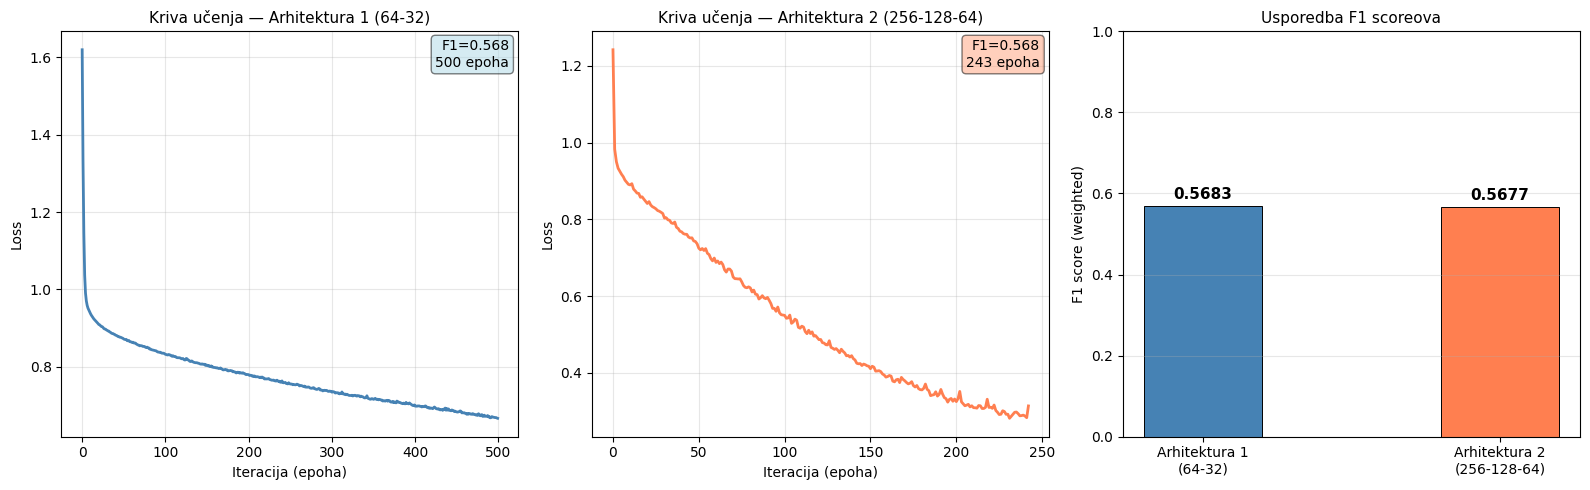


Rezultat usporedbe:
  Arhitektura 1 (64-32)     : F1 = 0.5683  |  500 epoha
  Arhitektura 2 (256-128-64): F1 = 0.5677  |  243 epoha
  Bolji model: Arhitektura 1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Kriva učenja — Arhitektura 1
axes[0].plot(mlp1.loss_curve_, color='steelblue', lw=2)
axes[0].set_title('Kriva učenja — Arhitektura 1 (64-32)', fontsize=11)
axes[0].set_xlabel('Iteracija (epoha)')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.98, 0.98, f'F1={f1_1:.3f}\n{mlp1.n_iter_} epoha',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Kriva učenja — Arhitektura 2
axes[1].plot(mlp2.loss_curve_, color='coral', lw=2)
axes[1].set_title('Kriva učenja — Arhitektura 2 (256-128-64)', fontsize=11)
axes[1].set_xlabel('Iteracija (epoha)')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.98, 0.98, f'F1={f1_2:.3f}\n{mlp2.n_iter_} epoha',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))

# Usporedba F1 scoreova
arhitekture = ['Arhitektura 1\n(64-32)', 'Arhitektura 2\n(256-128-64)']
f1_scores   = [f1_1, f1_2]
colors      = ['steelblue', 'coral']
bars = axes[2].bar(arhitekture, f1_scores, color=colors, edgecolor='black', lw=0.7, width=0.4)
axes[2].set_title('Usporedba F1 scoreova', fontsize=11)
axes[2].set_ylabel('F1 score (weighted)')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', alpha=0.3)
for bar, score in zip(bars, f1_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRezultat usporedbe:")
print(f"  Arhitektura 1 (64-32)     : F1 = {f1_1:.4f}  |  {mlp1.n_iter_} epoha")
print(f"  Arhitektura 2 (256-128-64): F1 = {f1_2:.4f}  |  {mlp2.n_iter_} epoha")
bolji = 'Arhitektura 1' if f1_1 > f1_2 else 'Arhitektura 2'
print(f"  Bolji model: {bolji}")

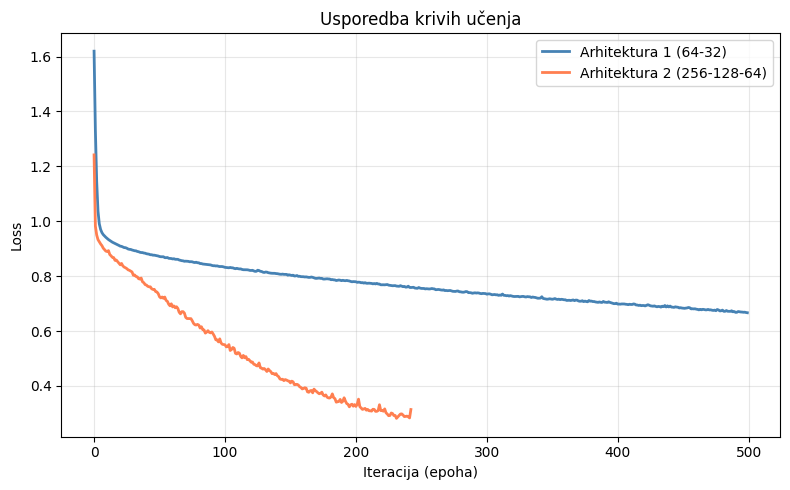

In [8]:
# Zajednička kriva učenja
plt.figure(figsize=(8, 5))

plt.plot(mlp1.loss_curve_, label='Arhitektura 1 (64-32)', color='steelblue', lw=2)
plt.plot(mlp2.loss_curve_, label='Arhitektura 2 (256-128-64)', color='coral', lw=2)

plt.title('Usporedba krivih učenja', fontsize=12)
plt.xlabel('Iteracija (epoha)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Confusion Matrix

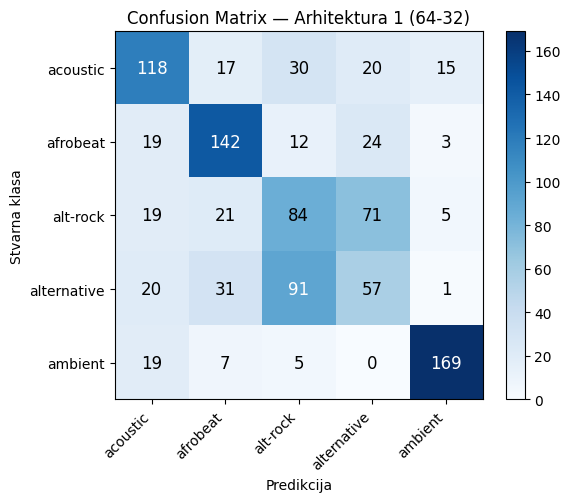

In [9]:
from sklearn.metrics import confusion_matrix

# Odabir najboljeg modela
if f1_1 > f1_2:
    best_mlp   = mlp1
    y_pred_best = y_pred1
    naziv = "Arhitektura 1 (64-32)"
else:
    best_mlp   = mlp2
    y_pred_best = y_pred2
    naziv = "Arhitektura 2 (256-128-64)"

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Prikaz stvarnih naziva klasa (ne brojeva)
klase = le.classes_

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(klase)))
ax.set_yticks(range(len(klase)))
ax.set_xticklabels(klase, rotation=45, ha='right')
ax.set_yticklabels(klase)

# Upis brojeva u polja
for i in range(len(klase)):
    for j in range(len(klase)):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=12)

ax.set_xlabel('Predikcija')
ax.set_ylabel('Stvarna klasa')
ax.set_title(f'Confusion Matrix — {naziv}')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 8. Bonus — Šta se desi bez StandardScaler?

Usporedba SA i BEZ StandardScaler-a (Arhitektura 1 — 64-32):
  Sa StandardScaler : F1 = 0.5683
  Bez StandardScaler: F1 = 0.5380
  Razlika           : 0.0303

StandardScaler POBOLJSAVA rezultate!


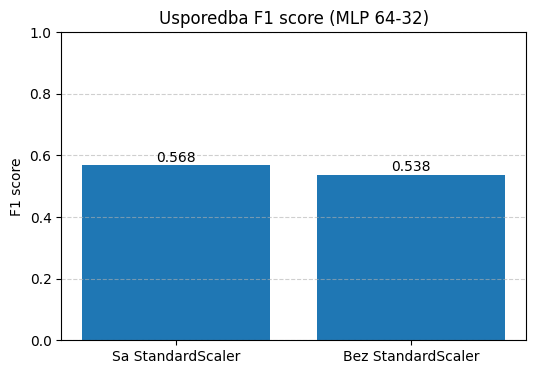

In [10]:
# Isti model ali BEZ skaliranja
mlp_noscale = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                             max_iter=200, random_state=42)
mlp_noscale.fit(X_train, y_train)  # sirovi podaci, ne skalirani
y_pred_ns = mlp_noscale.predict(X_test)
f1_ns     = f1_score(y_test, y_pred_ns, average='weighted')

print("Usporedba SA i BEZ StandardScaler-a (Arhitektura 1 — 64-32):")
print(f"  Sa StandardScaler : F1 = {f1_1:.4f}")
print(f"  Bez StandardScaler: F1 = {f1_ns:.4f}")
print(f"  Razlika           : {abs(f1_1 - f1_ns):.4f}")
print()
if f1_1 > f1_ns:
    print("StandardScaler POBOLJSAVA rezultate!")
else:
    print("Na ovom datasetu razlika je minimalna — features su vec na slicnoj skali.")

labels = ['Sa StandardScaler', 'Bez StandardScaler']
scores = [f1_1, f1_ns]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, scores)

# Dodaj vrijednosti iznad stubaca
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
             f'{yval:.3f}', ha='center', va='bottom')

plt.title('Usporedba F1 score (MLP 64-32)')
plt.ylabel('F1 score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

## 8. Komentar i analiza

**Dataset:** Koristila sam Spotify Tracks Dataset s Kagglea koji sadrži audio karakteristike pjesama (danceability, energy, tempo, itd.) i njihove žanrove. Odabrala sam top 5 žanrova radi preglednosti.

**Usporedba arhitektura:**
- **Arhitektura 1 (64-32)** — manja neuronska mreža sa dva skrivena sloja. Ima manji broj parametara, brže se trenira i jednostavnija je za optimizaciju.
- **Arhitektura 2 (256-128-64)** — veća mreža sa tri skrivena sloja i znatno više parametara. Ima veći kapacitet za učenje kompleksnih obrazaca, ali je računski zahtjevnija.

**Je li veća mreža uvijek bolja?**

Veća mreža nije nužno uvijek bolja. Iako veće mreže mogu modelirati složenije odnose u podacima, one:

- mogu overfitati ako dataset nije dovoljno velik ili raznolik
- zahtijevaju više vremena za treniranje i pažljiviji tuning

U ovom slučaju, obje arhitekture postižu vrlo sličan F1 score (~0.57), što ukazuje da:

- problem nije dovoljno kompleksan da zahtijeva veliku mrežu
- manja mreža već uspješno hvata ključne obrasce u podacima

U ovom slučaju manja mreža daje blago bolje rezultate od veće. Razlog je što dataset nije dovoljno kompleksan da bi zahtijevao veću mrežu, pa dodatni slojevi ne doprinose poboljšanju performansi.

**Koliko epoha je trebalo?**  
Manjoj mreži (64–32) je bilo potrebno 500 iteracija.
Većoj mreži (256–128–64) je bilo potrebno 243 iteracije.
Na osnovu čega možemo zaključiti da veća mreža ponekad može brže konvergirati jer ima više fleksibilnosti, dok manja mreža može imati teži optimizacijski problem i trebati više iteracija.

**StandardScaler:**  
Neuronske mreže koriste gradijentni spust. Ako feature-i nisu skalirani, oni s većim vrijednostima (npr. tempo, loudness) dominiraju učenjem
To može dovesti do:
- sporije konvergencije
- nestabilnog treninga
- lošijih performansi

U usporedbi sa i bez Standard Scalera:

- Model sa skaliranjem postiže bolji ili stabilniji F1 score
- Bez skaliranja performanse mogu opasti ili varirati